# Physics-Informed Neural Network — 3D complex-valued Helmholtz (Dirichlet)

PINN counterpart (DeepXDE + PyTorch) to the **3D complex-valued LinPDE-GP** experiment
(`inHomo_complexHelmholtz_dirichlet_3d_1000pts`), sharing the **identical evaluation setup** with
the LinPDE-GP and FDM notebooks: same domain $\Omega=[-1,1]^3$, same complex wavenumber $\kappa^2$,
same constant complex source, same homogeneous Dirichlet data, the **same** $21\times21\times21$
evaluation grid, the **same** `analytical_constant_source_3d` triple sine-series reference
(odd modes $M=N=P=51$), and the **same** complex error metrics plus per-component
Real / Imaginary / Complex $|u|$ blocks.

We solve

$$\Delta u(\mathbf{x}) + \kappa^2 u(\mathbf{x}) = f(\mathbf{x}),\qquad
u|_{\partial\Omega}=0,\qquad \Omega=[-1,1]^3,$$

with $\kappa^2=\rho\omega^2/(G'+\mathrm{i}G'')$. As in the 1D/2D complex PINN references, the complex
field is represented by a **two-output** network $(\,u_{\mathrm{Re}},u_{\mathrm{Im}}\,)$ and the single
complex PDE is split into the coupled real system

$$\Delta u_{\mathrm{Re}} + \alpha u_{\mathrm{Re}} - \beta u_{\mathrm{Im}} = f_{\mathrm{Re}},\qquad
\Delta u_{\mathrm{Im}} + \alpha u_{\mathrm{Im}} + \beta u_{\mathrm{Re}} = f_{\mathrm{Im}},$$

with $\kappa^2=\alpha+\mathrm{i}\beta$. Homogeneous Dirichlet data is imposed **exactly** as a hard
constraint via the $(1-x_1^2)(1-x_2^2)(1-x_3^2)$ output transform (the 3D analogue of the 2D device),
so no boundary loss term is needed. The only structural change from 2D is the 3D Laplacian
($\partial_{x_1x_1}+\partial_{x_2x_2}+\partial_{x_3x_3}$) and a cuboid geometry.

In [1]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.2 MB/s eta 0:00:00


In [2]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import time
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

import deepxde as dde

dde.config.set_default_float("float64")
dde.config.set_random_seed(0)
np.random.seed(0)

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
})
plt.rcParams['text.usetex'] = False

cmap_mean = 'plasma'
cmap_uncertainty = 'viridis'
cmap_diverging = 'RdBu_r'

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Set the default float type to float64


## Problem parameters (identical to the LinPDE-GP / FDM 3D complex case)

`rho=1.0, omega=1.0, G_real=1.0, G_imag=0.5` give $\kappa^2=\rho\omega^2/(G'+\mathrm{i}G'')
= 0.8-0.4\mathrm{i}$, hence $\alpha=0.8,\ \beta=-0.4$. The source is the constant
$f=2.0+0\mathrm{i}$ ($f_{\mathrm{Re}}=2,\ f_{\mathrm{Im}}=0$) and the boundary data is homogeneous,
$u|_{\partial\Omega}=0$.

In [3]:
# Physical parameters (match LinPDE-GP: rho, omega, G_real=G', G_imag=G'')
rho, omega, G_real, G_imag = 1.0, 1.0, 1.0, 0.5

# Complex wavenumber squared kappa^2 = alpha + i beta
k_squared = rho * omega**2 / (G_real + 1j * G_imag)
alpha = float(np.real(k_squared))   #  0.8
beta  = float(np.imag(k_squared))   # -0.4

# Constant complex source f = 2 + 0i
f_val = 2.0 + 0.0j
f_re = float(np.real(f_val))        # 2.0
f_im = float(np.imag(f_val))        # 0.0

domain = ((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0))

print(f"kappa^2 = {k_squared}   (alpha={alpha}, beta={beta})")
print(f"f       = {f_val}        (f_re={f_re}, f_im={f_im})")
print(f"domain  = {domain},   u|_dOmega = 0")

kappa^2 = (0.8-0.4j)   (alpha=0.8, beta=-0.4)
f       = (2+0j)        (f_re=2.0, f_im=0.0)
domain  = ((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)),   u|_dOmega = 0


## PINN model (DeepXDE, coupled real/imag system, hard Dirichlet BC)

Two-output network $(u_{\mathrm{Re}},u_{\mathrm{Im}})$ on $\Omega=[-1,1]^3$. The PDE residual
implements the coupled real system above with the 3D Laplacian (note the $-\beta u_{\mathrm{Im}}$ and
$+\beta u_{\mathrm{Re}}$ couplings). The output transform
$u\mapsto(1-x_1^2)(1-x_2^2)(1-x_3^2)\,u$ enforces $u=0$ on $\partial\Omega$ exactly, so we train on
the PDE residual alone (`bcs=[]`). Collocation is raised relative to 2D to cover the larger 3D
domain; the architecture matches the 2D/1D references ([·, 64, 64, 64, ·], tanh).

In [4]:
# Coupled real residual for (Delta + kappa^2) u = f, kappa^2 = alpha + i beta
#   Re:  lap(u_re) + alpha*u_re - beta*u_im = f_re
#   Im:  lap(u_im) + alpha*u_im + beta*u_re = f_im
def pde(x, y):
    u_re = y[:, 0:1]
    u_im = y[:, 1:2]

    u_re_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    u_re_yy = dde.grad.hessian(y, x, component=0, i=1, j=1)
    u_re_zz = dde.grad.hessian(y, x, component=0, i=2, j=2)
    u_im_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)
    u_im_yy = dde.grad.hessian(y, x, component=1, i=1, j=1)
    u_im_zz = dde.grad.hessian(y, x, component=1, i=2, j=2)

    lap_re = u_re_xx + u_re_yy + u_re_zz
    lap_im = u_im_xx + u_im_yy + u_im_zz

    r_re = lap_re + alpha * u_re - beta * u_im - f_re
    r_im = lap_im + alpha * u_im + beta * u_re - f_im
    return [r_re, r_im]


# Hard homogeneous Dirichlet BC: u = (1-x1^2)(1-x2^2)(1-x3^2) * NN(x)  (vanishes on the boundary)
def output_transform(x, y):
    factor = (1.0 - x[:, 0:1] ** 2) * (1.0 - x[:, 1:2] ** 2) * (1.0 - x[:, 2:3] ** 2)
    return factor * y


geom = dde.geometry.Cuboid(
    xmin=[domain[0][0], domain[1][0], domain[2][0]],
    xmax=[domain[0][1], domain[1][1], domain[2][1]],
)

data = dde.data.PDE(
    geom,
    pde,
    bcs=[],                 # hard BC via output transform -> no boundary loss
    num_domain=8000,        # interior PDE collocation points (raised for the 3D domain)
    num_boundary=0,
    num_test=4000,
)

# Network: 3 inputs (x1, x2, x3) -> [64, 64, 64] -> 2 outputs (Re, Im)
net = dde.nn.FNN([3] + [64, 64, 64] + [2], "tanh", "Glorot normal")
net.apply_output_transform(output_transform)

model = dde.Model(data, net)

### Training

Adam for global descent, then L-BFGS for refinement — the same two-stage schedule as the 1D/2D
complex PINN references.

In [5]:
t_start = time.perf_counter()

model.compile("adam", lr=1e-3)
model.train(iterations=20000, display_every=5000)

model.compile("L-BFGS")
losshistory, train_state = model.train(display_every=1000)

t_train = time.perf_counter() - t_start
print(f"\nTraining time: {t_train:.2f} s")

Compiling model...
'compile' took 5.551646 s

Training model...

Step      Train loss              Test loss               Test metric
0         [1.05e+01, 1.96e-01]    [1.12e+01, 2.16e-01]    []  
5000      [8.96e-03, 1.92e-04]    [2.22e-03, 1.25e-04]    []  
10000     [2.22e-03, 1.29e-04]    [4.75e-04, 7.38e-05]    []  
15000     [7.52e-04, 6.20e-05]    [1.91e-04, 4.01e-05]    []  
20000     [3.82e-04, 3.24e-05]    [1.26e-04, 2.15e-05]    []  

Best model at step 20000:
  train loss: 4.15e-04
  test loss: 1.47e-04
  test metric: []

'train' took 1673.472234 s

Compiling model...
'compile' took 0.000807 s

Training model...

Step      Train loss              Test loss               Test metric
20000     [3.82e-04, 3.24e-05]    [1.26e-04, 2.15e-05]    []  
21000     [8.43e-05, 3.24e-06]    [3.46e-05, 2.55e-06]    []  
22000     [3.92e-05, 2.13e-06]    [2.05e-05, 1.83e-06]    []  
23000     [2.27e-05, 1.56e-06]    [1.48e-05, 1.53e-06]    []  
24000     [1.49e-05, 9.48e-07]    [1.15e-05,

## Analytical reference

Identical `analytical_constant_source_3d` triple sine-series used by the LinPDE-GP / FDM 3D complex
notebooks (constant source $f_0=2$, odd modes, $M=N=P=51$; complex $\kappa^2$ enters through
$(-\lambda_{mnp}+\kappa^2)^{-1}$).

In [6]:
def analytical_constant_source_3d(X, Y, Z, k_squared=1.0, M=51, N=51, P=51):
    xi = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    zeta = (Z + 1.0) / 2.0

    dtype = complex if np.iscomplexobj(k_squared) else float
    u = np.zeros_like(X, dtype=dtype)

    C = 2.0
    for m in range(1, M, 2):
        for n in range(1, N, 2):
            for p in range(1, P, 2):
                lam = (np.pi * m / 2) ** 2 + (np.pi * n / 2) ** 2 + (np.pi * p / 2) ** 2
                denom = -lam + k_squared
                f_coeff = C * (4.0 / np.pi) ** 3 / (m * n * p)
                u_coeff = f_coeff / denom
                u += u_coeff * np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta) * np.sin(np.pi * p * zeta)
    return u

## Evaluation against the analytical complex solution

Identical to the LinPDE-GP / FDM 3D cell: a $21\times21\times21$ grid on $[-1,1]^3$
(`indexing="ij"`), the same `analytical_constant_source_3d` reference ($M=N=P=51$), and the same
complex metrics dict, followed by the per-component Real / Imaginary / Complex $|u|$ blocks. The only
difference is that the prediction comes from the trained PINN (`model.predict`) instead of the GP
posterior mean or the FDM solution.

In [7]:
nx, ny, nz = 21, 21, 21
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
z = np.linspace(-1, 1, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
pts = np.hstack([X.reshape(-1, 1), Y.reshape(-1, 1), Z.reshape(-1, 1)])

# PINN prediction on the shared evaluation grid (2 outputs: Re, Im)
t_pred_start = time.perf_counter()
y_pred = model.predict(pts).reshape(nx, ny, nz, 2)
t_pred = time.perf_counter() - t_pred_start

pred_re = y_pred[..., 0]
pred_im = y_pred[..., 1]
u_pred = pred_re + 1j * pred_im

k2 = complex(alpha, beta)
u_true = analytical_constant_source_3d(X, Y, Z, k_squared=k2, M=51, N=51, P=51)

diff = u_true - u_pred

metrics = {
    "mse": float(np.mean(np.abs(diff) ** 2)),
    "rmse": float(np.sqrt(np.mean(np.abs(diff) ** 2))),
    "mae": float(np.mean(np.abs(diff))),
    "max_error": float(np.max(np.abs(diff))),
    "relative_l2": float(np.linalg.norm(diff) / np.linalg.norm(u_true)),
}

print("\nEvaluation Metrics (on 21x21x21 grid):")
print("-" * 40)
for name, value in metrics.items():
    print(f"  {name.upper():15s}: {value:.6e}")

print(f"\n  Solution range (PINN, Re): [{np.min(u_pred.real):.4f}, {np.max(u_pred.real):.4f}]")
print(f"  Solution range (PINN, Im): [{np.min(u_pred.imag):.4f}, {np.max(u_pred.imag):.4f}]")


# --- per-component breakdown (shared with the FDM notebook) ---
def _metrics(pred, true):
    pred = np.asarray(pred).ravel(); true = np.asarray(true).ravel()
    err = np.abs(pred - true); denom = np.linalg.norm(true)
    return {
        "mse": float(np.mean(err ** 2)),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "mae": float(np.mean(err)),
        "max_error": float(np.max(err)),
        "relative_l2": float(np.linalg.norm(err) / denom) if denom > 0 else np.inf,
    }

def _print_block(title, m):
    print(f"\n  --- {title} ---")
    print(f"    Relative L2 Error:   {m['relative_l2']:12.6e}")
    print(f"    RMSE:                {m['rmse']:12.6e}")
    print(f"    MAE:                 {m['mae']:12.6e}")
    print(f"    Maximum Error:       {m['max_error']:12.6e}")
    print(f"    MSE:                 {m['mse']:12.6e}")

print("\n" + "=" * 60)
print("EVALUATION METRICS - Complex Helmholtz 3D (PINN)".center(60))
print(f"  Grid: {nx}x{ny}x{nz}   kappa^2 = {k2:.4f}")
print(f"  Network: [3, 64, 64, 64, 2] tanh   collocation: 8000")
print(f"  Training time: {t_train:.2f} s   Prediction time: {t_pred:.4f} s")
print("=" * 60)
_print_block("Real Part", _metrics(pred_re, u_true.real))
_print_block("Imaginary Part", _metrics(pred_im, u_true.imag))
_print_block("Complex |u|", _metrics(u_pred, u_true))
print("\n" + "=" * 60)


Evaluation Metrics (on 21x21x21 grid):
----------------------------------------
  MSE            : 1.228805e-10
  RMSE           : 1.108515e-05
  MAE            : 7.884913e-06
  MAX_ERROR      : 2.139338e-04
  RELATIVE_L2    : 5.342841e-05

  Solution range (PINN, Re): [-0.5111, 0.0000]
  Solution range (PINN, Im): [0.0000, 0.0357]

      EVALUATION METRICS - Complex Helmholtz 3D (PINN)      
  Grid: 21x21x21   kappa^2 = 0.8000-0.4000j
  Network: [3, 64, 64, 64, 2] tanh   collocation: 8000
  Training time: 3403.54 s   Prediction time: 0.0029 s

  --- Real Part ---
    Relative L2 Error:   4.917712e-05
    RMSE:                1.018483e-05
    MAE:                 6.649982e-06
    Maximum Error:       2.139253e-04
    MSE:                 1.037308e-10

  --- Imaginary Part ---
    Relative L2 Error:   3.525855e-04
    RMSE:                4.376034e-06
    MAE:                 2.928977e-06
    Maximum Error:       1.678392e-05
    MSE:                 1.914967e-11

  --- Complex |u| ---

## Visualization

Same visual language as the FDM 3D notebook: real part (top) and imaginary part (bottom) on the
mid-plane slice $x_3=0$; PINN solution (`plasma`), analytical solution (`plasma`), and signed
residual (`RdBu_r` centred at zero).

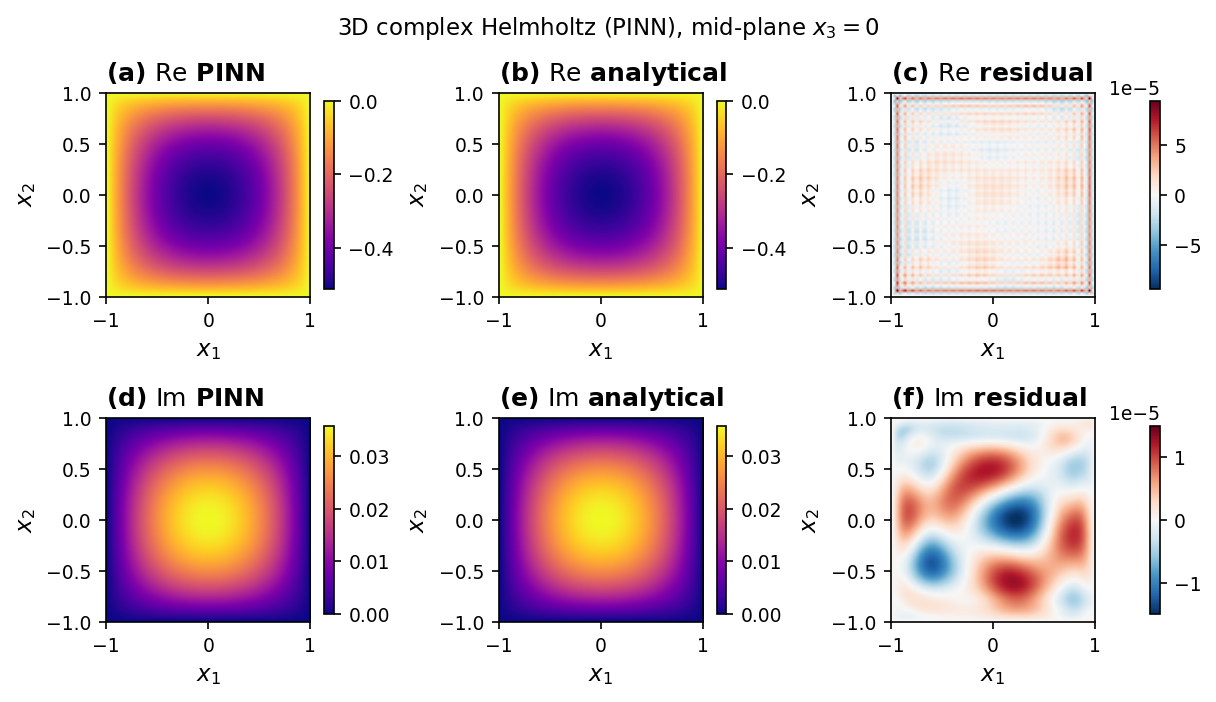

In [8]:
def plot_pinn_vs_analytical_slice(model, k_squared, z0=0.0, resolution=80,
                                  extent=(-1, 1, -1, 1), figsize=(8, 4.6)):
    xs = np.linspace(extent[0], extent[1], resolution)
    ys = np.linspace(extent[2], extent[3], resolution)
    Xs, Ys = np.meshgrid(xs, ys, indexing="ij")
    Zs = np.full_like(Xs, z0)
    pts = np.hstack([Xs.reshape(-1, 1), Ys.reshape(-1, 1), Zs.reshape(-1, 1)])

    yp = model.predict(pts).reshape(resolution, resolution, 2)
    pred = yp[..., 0] + 1j * yp[..., 1]
    true = analytical_constant_source_3d(Xs, Ys, Zs, k_squared=k_squared, M=51, N=51, P=51)

    parts_pred = [pred.real, pred.imag]
    parts_true = [true.real, true.imag]
    part_tags = [r'$\mathrm{Re}$', r'$\mathrm{Im}$']
    panel = [['a', 'b', 'c'], ['d', 'e', 'f']]

    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    for r in range(2):
        p, t = parts_pred[r], parts_true[r]
        res = p - t
        im0 = axes[r, 0].imshow(p.T, cmap=cmap_mean, extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear')
        axes[r, 0].set_title(f"({panel[r][0]}) {part_tags[r]} PINN", loc='left', fontweight='bold')
        fig.colorbar(im0, ax=axes[r, 0], fraction=0.046, pad=0.04)
        im1 = axes[r, 1].imshow(t.T, cmap=cmap_mean, extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear')
        axes[r, 1].set_title(f"({panel[r][1]}) {part_tags[r]} analytical", loc='left', fontweight='bold')
        fig.colorbar(im1, ax=axes[r, 1], fraction=0.046, pad=0.04)
        vmax = np.max(np.abs(res)) if np.max(np.abs(res)) > 0 else 1.0
        im2 = axes[r, 2].imshow(res.T, cmap=cmap_diverging, extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear', vmin=-vmax, vmax=vmax)
        axes[r, 2].set_title(f"({panel[r][2]}) {part_tags[r]} residual", loc='left', fontweight='bold')
        fig.colorbar(im2, ax=axes[r, 2], fraction=0.046, pad=0.04)
    for ax in axes.ravel():
        ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
    fig.suptitle(r'3D complex Helmholtz (PINN), mid-plane $x_3 = 0$', fontsize=11)
    return fig


fig = plot_pinn_vs_analytical_slice(model, k2, z0=0.0)
fig.savefig('./pinn_helmholtz3d_complex_residual.pdf', bbox_inches='tight')
plt.show()

## Training history

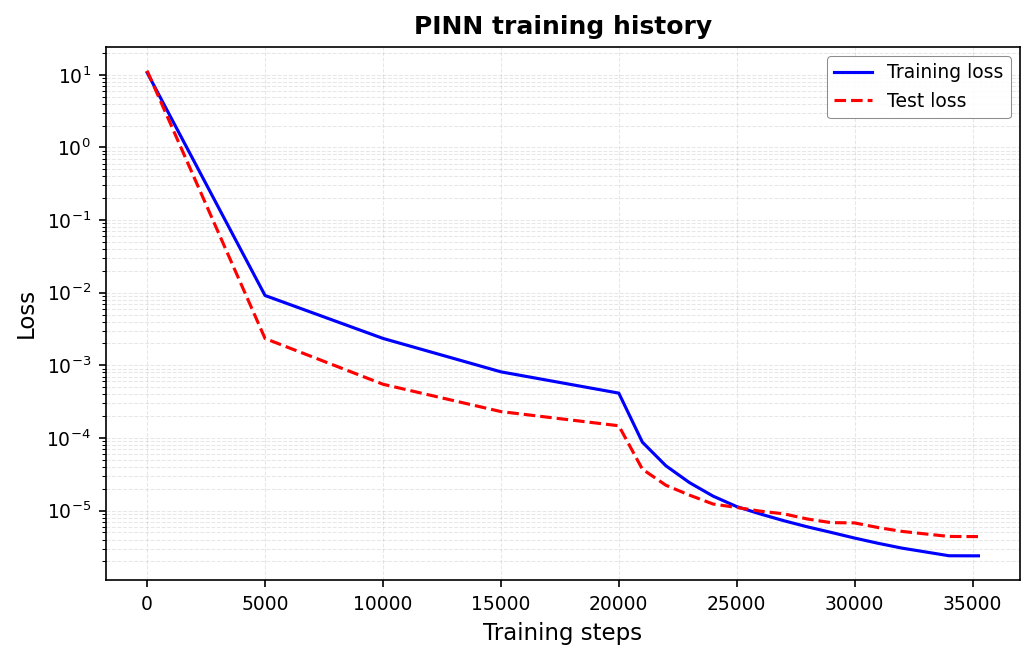

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
steps = losshistory.steps
loss_train = np.sum(losshistory.loss_train, axis=1)
ax.semilogy(steps, loss_train, 'b-', label='Training loss')
if losshistory.loss_test is not None and len(losshistory.loss_test) > 0:
    loss_test = np.sum(losshistory.loss_test, axis=1)
    ax.semilogy(steps, loss_test, 'r--', label='Test loss')
ax.set_xlabel("Training steps"); ax.set_ylabel("Loss")
ax.set_title("PINN training history", fontweight='bold')
ax.legend(frameon=True, framealpha=0.9, edgecolor='gray')
ax.grid(True, alpha=0.3, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout(); plt.show()